# Correlating stock index performance with macroeconomic indicators using Regression

The target variables are: 
- Target (Y): daily change percentage 
- Predictors (X): GDP growth, inflation, interest rate, unemployment

Authors: Lohane da Cruz Evora and Irena Nguyen (NGUYEN THI HONG HAI)

## Install library

This project uses the following libraries:
- numpy
- pandas
...

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import math
# For prediction
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
# note! [delete later!]: ModuleNotFoundError when importing the libraries --> view >> terminal >> pip install numpy pandas matplotlib seaborn scikit-learn kagglehub

## Dataset

### Introducing the dataset

This dataset contains information on global stock markets and macroeconomic indicators for 39 countries as of 2024-08-15. It covers countries across North America, Europe, Asia, including both developed (US, Japan, Germany, UK) and emerging economies (China, India, Brazil, etc.).

#### Key Features:
- Market Data: Country, stock index name, index value, daily change %.

- Economic Indicators: GDP growth rate, inflation, interest rates, unemployment.

- Others features: 
    - Financial Market Metrics: Market capitalization, bond yields, credit rating.
    - Commodities & Assets: Oil price, gold price, commodity index.
    - Risk & Stability: Political risk score, banking sector health, real estate index.
    - Trade & Growth: Export and import growth percentages.
- For the purpose of this project, only the features regarding the market as well as the economic indicators are included for the study.

In [24]:
# Importing dataset
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("imaadmahmood/global-finance-and-economic-indicators-dataset-2024")

files = os.listdir(path)
print(files)

file_path = os.path.join(path, files[0])  # take first file
df = pd.read_csv(file_path)

df.head()

['Global finance data.csv']


,Country,Date,Stock_Index,Index_Value,Daily_Change_Percent,Market_Cap_Trillion_USD,GDP_Growth_Rate_Percent,Inflation_Rate_Percent,Interest_Rate_Percent,Unemployment_Rate_Percent,...,Commodity_Index,Oil_Price_USD_Barrel,Gold_Price_USD_Ounce,Bond_Yield_10Y_Percent,Credit_Rating,Political_Risk_Score,Banking_Sector_Health,Real_Estate_Index,Export_Growth_Percent,Import_Growth_Percent
0,United States,2024-08-15,S&P_500,5437.2,0.34,51.2,2.8,2.9,5.50,3.7,...,1.12,77.85,2487.5,4.25,AAA,8.1,Strong,145.6,3.2,2.8
1,China,2024-08-15,Shanghai_Composite,2891.6,-0.82,12.4,5.2,0.8,3.10,5.2,...,0.98,77.85,2487.5,2.15,A+,6.7,Moderate,98.7,8.9,6.1
2,Japan,2024-08-15,Nikkei_225,36789.1,1.24,6.8,0.9,2.8,-0.10,2.4,...,1.05,77.85,2487.5,0.89,A+,8.4,Strong,89.3,5.1,4.7
3,Germany,2024-08-15,DAX,18234.5,0.67,2.9,0.3,2.2,4.50,3.1,...,1.08,77.85,2487.5,2.31,AAA,8.7,Strong,112.4,2.1,1.8
4,United Kingdom,2024-08-15,FTSE_100,8156.3,-0.15,3.1,1.1,2.0,5.25,4.2,...,1.06,77.85,2487.5,3.89,AA,7.9,Moderate,97.8,0.9,1.2


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 26 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              39 non-null     str    
 1   Date                                 39 non-null     str    
 2   Stock_Index                          39 non-null     str    
 3   Index_Value                          39 non-null     float64
 4   Daily_Change_Percent                 39 non-null     float64
 5   Market_Cap_Trillion_USD              39 non-null     float64
 6   GDP_Growth_Rate_Percent              39 non-null     float64
 7   Inflation_Rate_Percent               39 non-null     float64
 8   Interest_Rate_Percent                39 non-null     float64
 9   Unemployment_Rate_Percent            39 non-null     float64
 10  Currency_Code                        39 non-null     str    
 11  Exchange_Rate_USD                    39 non-n

In [25]:
selected_columns = [
    "Country",
    "Index_Value",
    "Daily_Change_Percent",
    "GDP_Growth_Rate_Percent",
    "Inflation_Rate_Percent",
    "Interest_Rate_Percent",
    "Unemployment_Rate_Percent"
] # Only one date >>> drop column 'DATE'

df = df[selected_columns]

df.head()

,Country,Index_Value,Daily_Change_Percent,GDP_Growth_Rate_Percent,Inflation_Rate_Percent,Interest_Rate_Percent,Unemployment_Rate_Percent
0,United States,5437.2,0.34,2.8,2.9,5.50,3.7
1,China,2891.6,-0.82,5.2,0.8,3.10,5.2
2,Japan,36789.1,1.24,0.9,2.8,-0.10,2.4
3,Germany,18234.5,0.67,0.3,2.2,4.50,3.1
4,United Kingdom,8156.3,-0.15,1.1,2.0,5.25,4.2


In [7]:
# df's info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    39 non-null     str    
 1   Index_Value                39 non-null     float64
 2   Daily_Change_Percent       39 non-null     float64
 3   GDP_Growth_Rate_Percent    39 non-null     float64
 4   Inflation_Rate_Percent     39 non-null     float64
 5   Interest_Rate_Percent      39 non-null     float64
 6   Unemployment_Rate_Percent  39 non-null     float64
dtypes: float64(6), str(1)
memory usage: 2.3 KB


### Data prepocessing

In [26]:
# Checking for missing values
df_na = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df)) * 100
})

df_na # No 

,Missing Values,Percentage (%)
Country,0,0.0
Index_Value,0,0.0
Daily_Change_Percent,0,0.0
GDP_Growth_Rate_Percent,0,0.0
Inflation_Rate_Percent,0,0.0
Interest_Rate_Percent,0,0.0
Unemployment_Rate_Percent,0,0.0


## Analysis

### Exploratory Data Analysis

In [9]:
# Descriptive statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Index_Value,39.0,59964.774359,249537.018541,889.30,2711.80,8156.30,23012.25,1567890.20
Daily_Change_Percent,39.0,0.654103,0.834672,-1.23,0.31,0.67,0.89,3.45
GDP_Growth_Rate_Percent,39.0,2.415385,1.874558,-1.90,1.15,2.40,3.15,6.80
Inflation_Rate_Percent,39.0,11.023077,34.828629,-0.40,1.95,2.80,4.30,211.40
Interest_Rate_Percent,39.0,10.643590,21.866714,-0.10,4.05,4.75,6.50,133.00
Unemployment_Rate_Percent,39.0,5.887179,4.636138,1.20,3.30,5.10,7.30,28.70


In [10]:
# Descriptive statistics for objects columns
df.describe(include=['object', 'string']).T

,count,unique,top,freq
Country,39,39,United States,1


#### Correlation matrix

<Axes: >

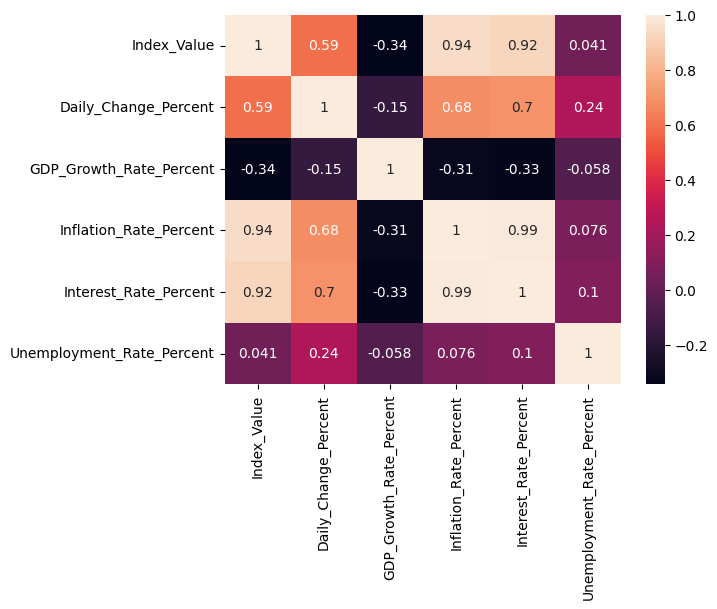

In [13]:
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True)

#### Outliers

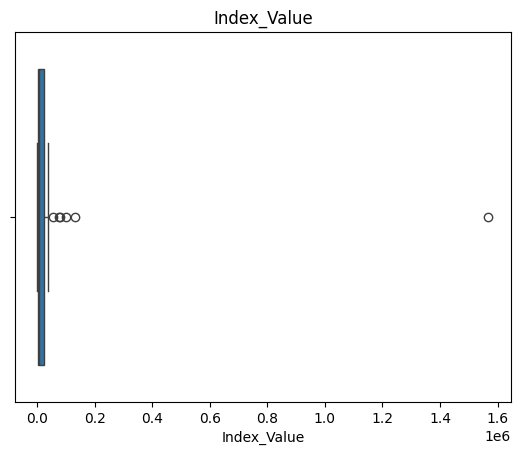

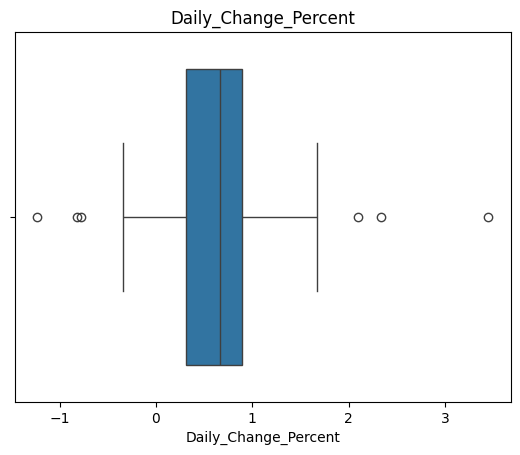

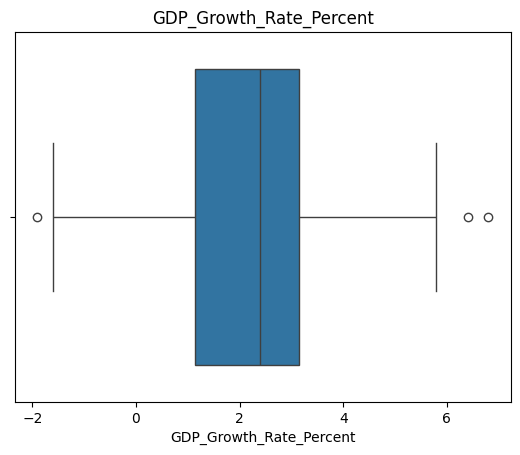

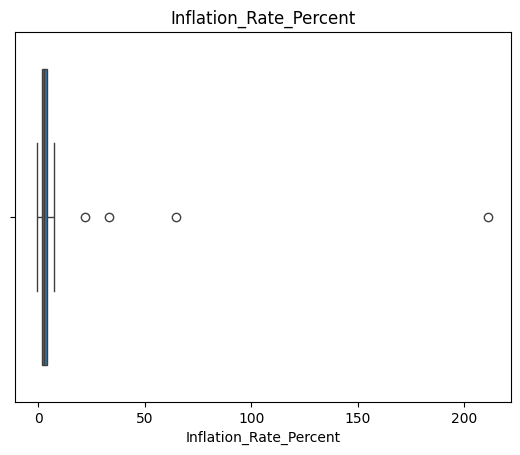

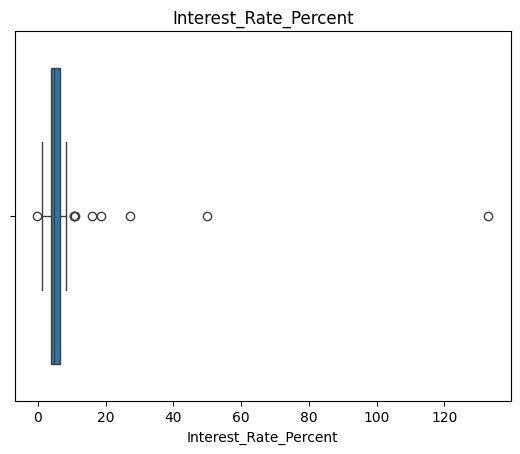

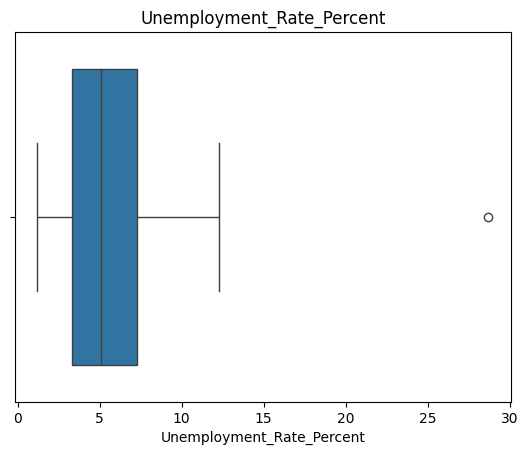

In [21]:
for col in df.select_dtypes(include='number').columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

There are extreme outliers within the data -> since linear regression minimizes squared error, outliers will distort coefficients and reduce model accuracy. Therefore it's important to removes any extreme outliners using the IQR (interquartile range) method

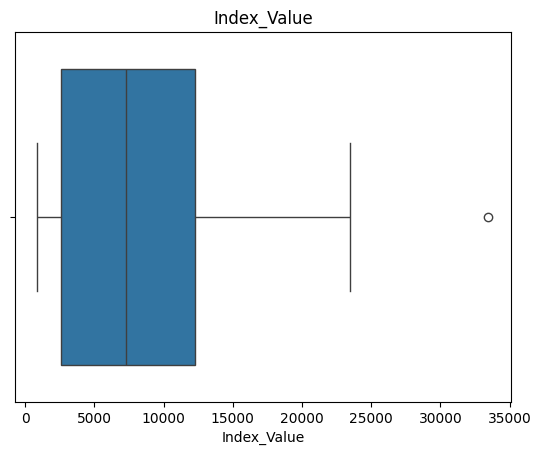

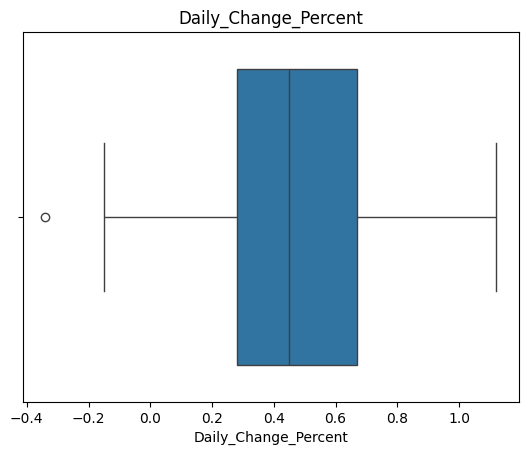

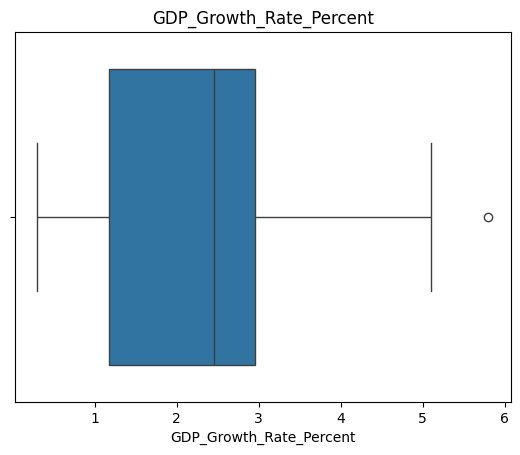

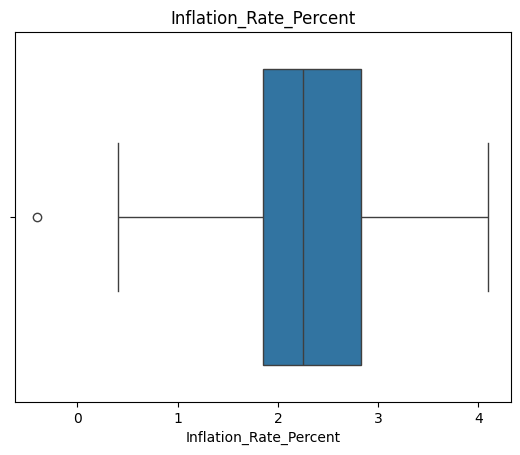

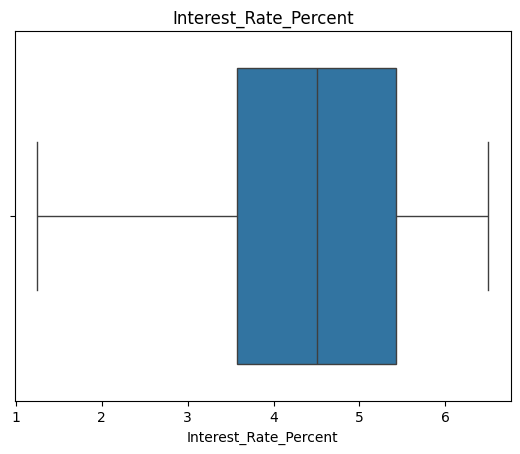

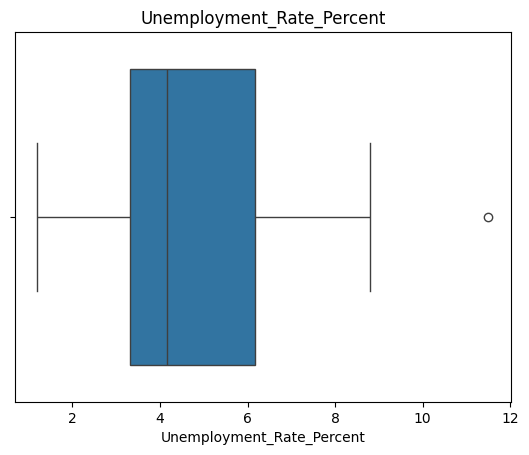

In [35]:
df_clean = df.copy()

for col in df.select_dtypes(include='number').columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower) & (df_clean[col] <= upper)
    ]
for col in df_clean.select_dtypes(include='number').columns:
    sns.boxplot(x=df_clean[col])
    plt.title(col)
    plt.show()

#### Relationship with Target

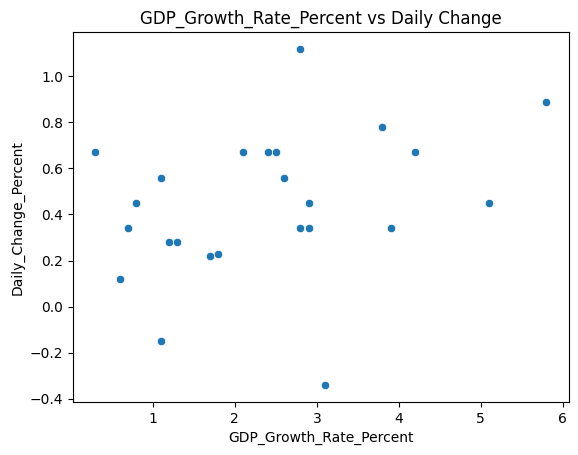

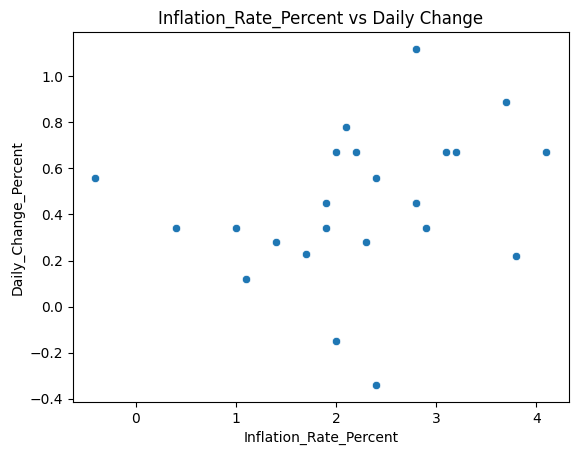

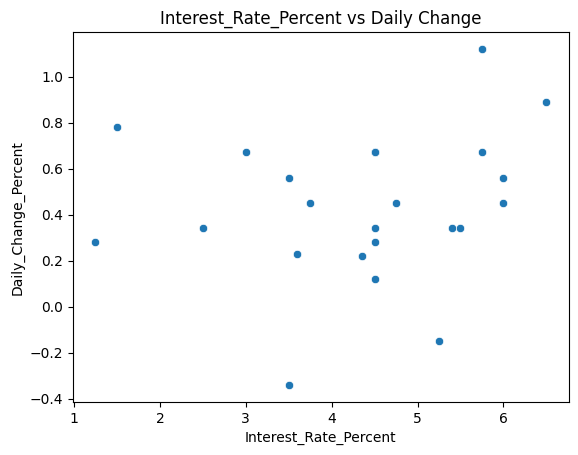

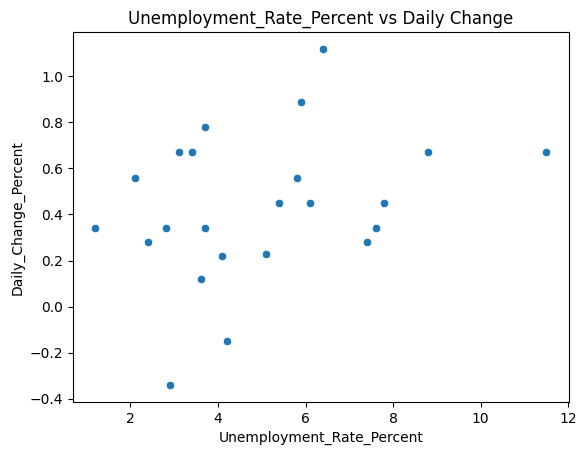

In [37]:
features = [
    "GDP_Growth_Rate_Percent",
    "Inflation_Rate_Percent",
    "Interest_Rate_Percent",
    "Unemployment_Rate_Percent"
]

for col in features:
    sns.scatterplot(x=df_clean[col], y=df_clean["Daily_Change_Percent"])
    plt.title(f"{col} vs Daily Change")
    plt.show()

#### Pair plot

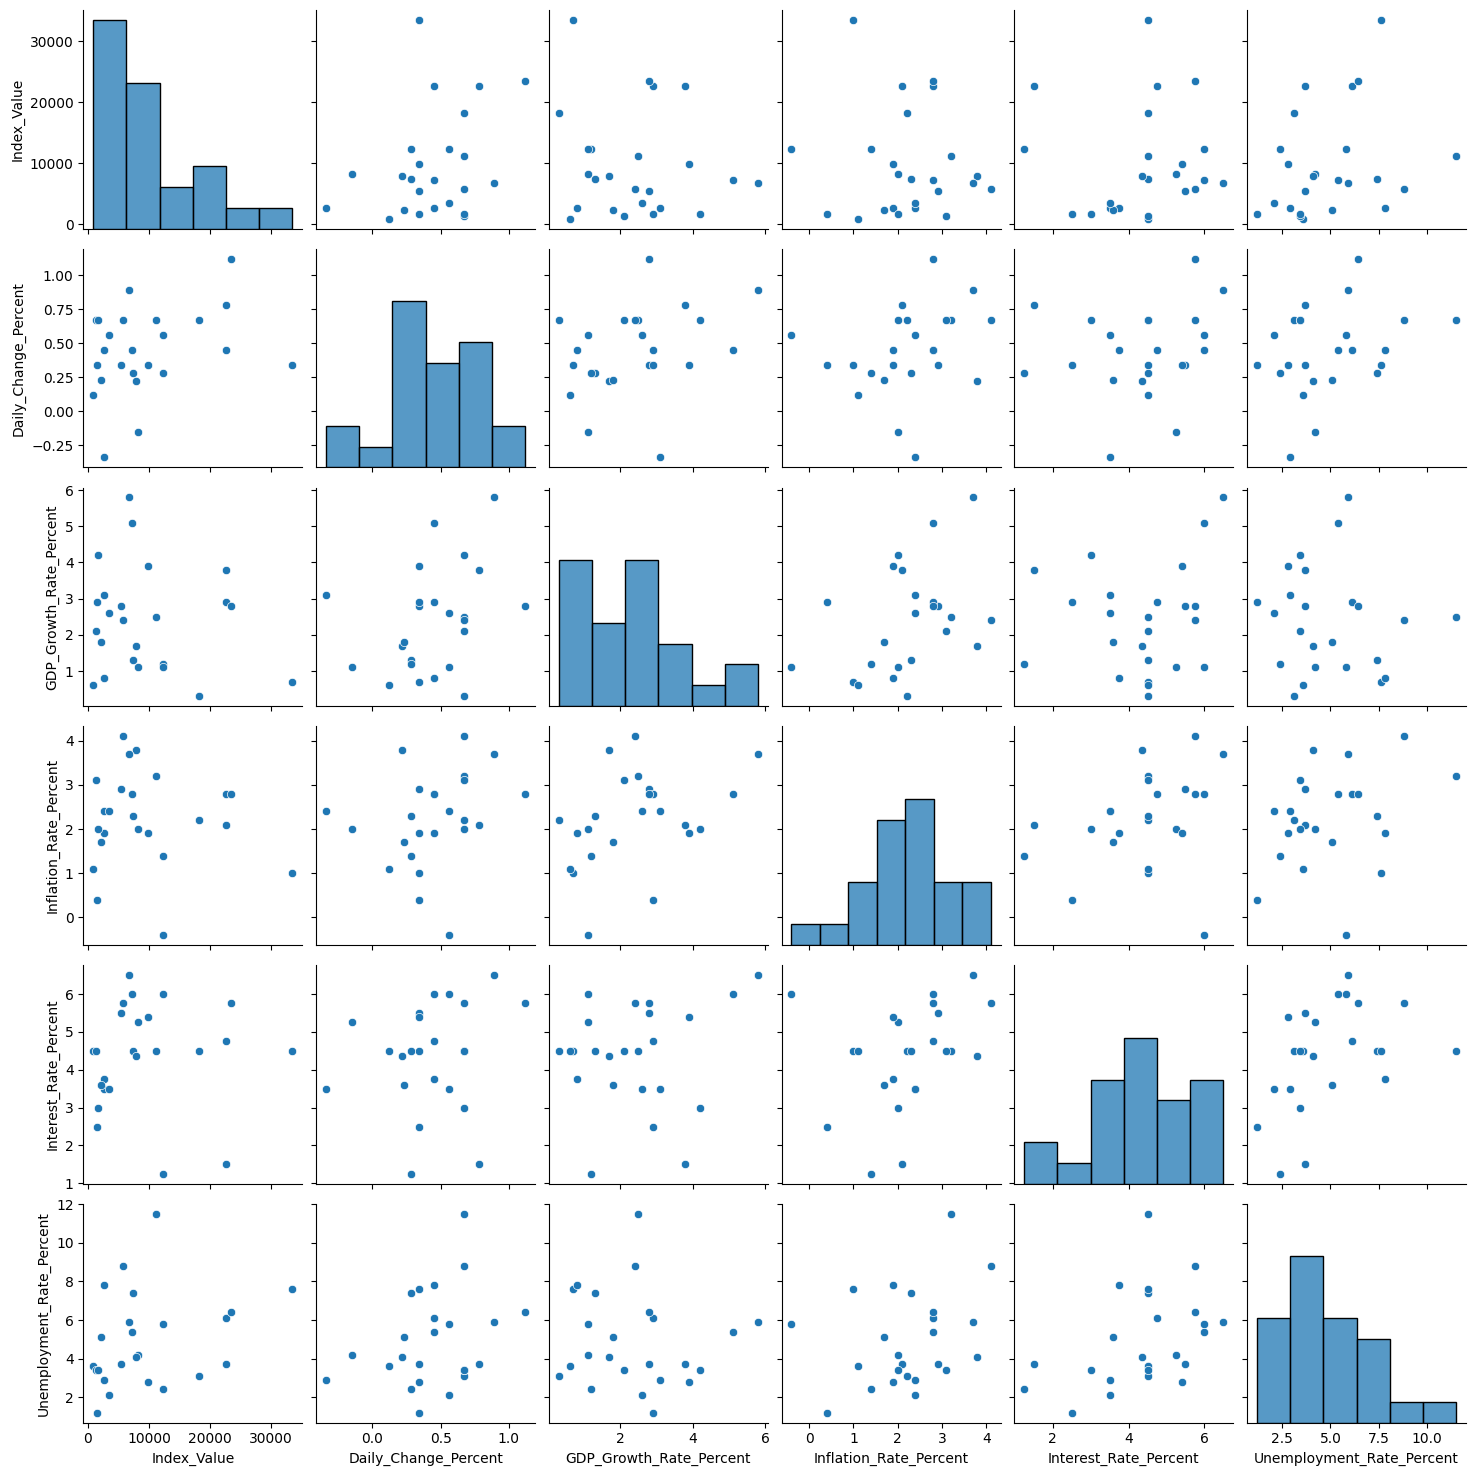

In [38]:
sns.pairplot(df_clean)
plt.show()

### Preprocessing 

In [ ]:
head(df)

,Feature,VIF
0,Index_Value,2.406167
1,GDP_Growth_Rate_Percent,4.655848
2,Inflation_Rate_Percent,7.896002
3,Interest_Rate_Percent,10.267131
4,Unemployment_Rate_Percent,7.765556


### Regression

Our regression model:
$$
Y = \beta_0 + \beta_1 (\text{GDP Growth}) + \beta_2 (\text{Inflation}) + \beta_3 (\text{Interest Rate}) + \beta_4 (\text{Unemployment}) + \varepsilon
$$